# Dimensionality Reduction on Genomic Sequences using Principal Component Analysis (PCA)

This reproducible analysis notebook demonstrates how to generate a genomic sequence feature matrix, 
perform Principal Component Analysis (PCA), and interpret the results through premium, high-quality plots.

### Biological Concept: Genomic Signatures ($k$-mer Frequencies)
Genomes differ in their nucleotide composition. A common way to represent genome sequences numerically without 
aligning them is through **$k$-mer frequency profiling**. A $k$-mer is a sequence of length $k$. 
For example, with $k=3$ (codons/triplets), there are $4^3 = 64$ possible trinucleotides (AAA, AAC, ..., TTT).

Sequences from related organisms tend to share similar $k$-mer distributions (genomic signatures), influenced 
heavily by GC-content, codon usage bias, and biological motifs. 

In this notebook, we:
1. Synthesize a **genomic test matrix** representing DNA sequences from three distinct artificial bacterial species 
   characterized by high, medium, and low GC content.
2. Extract their **$k$-mer frequency profiles**.
3. Perform **PCA** to project these high-dimensional genomic signatures ($64$ dimensions) into a $2$D space.
4. Analyze which $k$-mers drive the differences using a **loadings analysis**.

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set aesthetic defaults for premium publication-quality figures
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})
sns.set_theme(style="ticks")

## 1. Creating the Genomic Test Matrix
We will define functions to simulate DNA sequences and extract their $k$-mer frequencies.
Each sequence belongs to one of three hypothetical species:
- **Species A (Low GC)**: ~30% GC content
- **Species B (Medium GC)**: ~50% GC content
- **Species C (High GC)**: ~70% GC content

In [3]:
def generate_random_dna(length, gc_content, seed=None):
    """
    Generates a synthetic DNA sequence of a specified length and GC content.
    
    Parameters:
    -----------
    length : int
        Length of the DNA sequence in base pairs.
    gc_content : float
        Target fraction of G and C nucleotides (between 0.0 and 1.0).
    seed : int, optional
        Seed for reproducibility.
        
    Returns:
    --------
    str: The synthesized DNA sequence.
    """
    if seed is not None:
        random.seed(seed)
        
    p_gc = gc_content / 2.0
    p_at = (1.0 - gc_content) / 2.0
    
    # Probability distribution for A, C, G, T
    probabilities = [p_at, p_gc, p_gc, p_at]  # A, C, G, T
    nucleotides = ['A', 'C', 'G', 'T']
    
    seq = random.choices(nucleotides, weights=probabilities, k=length)
    return "".join(seq)

def get_all_kmers(k):
    """Generates all possible k-mers of length k using nucleotide alphabet."""
    import itertools
    return ["".join(p) for p in itertools.product(['A', 'C', 'G', 'T'], repeat=k)]

def extract_kmer_frequencies(sequence, k=3):
    """
    Counts and normalizes k-mer frequencies in a sequence.
    
    Parameters:
    -----------
    sequence : str
        DNA sequence.
    k : int
        Length of the k-mer.
        
    Returns:
    --------
    dict: Normalized frequencies (probabilities summing to 1.0).
    """
    kmers = get_all_kmers(k)
    kmer_counts = {km: 0 for km in kmers}
    
    # Slide a window of size k across the sequence
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in kmer_counts:
            kmer_counts[kmer] += 1
            
    total_kmers = sum(kmer_counts.values())
    if total_kmers > 0:
        # Normalize to obtain frequencies (relative abundances)
        kmer_freqs = {km: count / total_kmers for km, count in kmer_counts.items()}
    else:
        kmer_freqs = {km: 0.0 for km in kmers}
        
    return kmer_freqs

### Generating the Test Dataset
We generate 15 genomic sequences: 5 samples per species.
Then we construct a DataFrame where each row is a sample and each column is a 3-mer frequency (64 features).

In [4]:
# Setting a fixed seed for deterministic reproducibility
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)

species_metadata = [
    {"Species": "Species_A (Low GC)", "GC": 0.30, "count": 5},
    {"Species": "Species_B (Medium GC)", "GC": 0.50, "count": 5},
    {"Species": "Species_C (High GC)", "GC": 0.70, "count": 5}
]

sequences_db = []
metadata_list = []

sample_id = 1
for sp_info in species_metadata:
    name = sp_info["Species"]
    gc = sp_info["GC"]
    for i in range(sp_info["count"]):
        seq_name = f"Sample_{sample_id:02d}_{name.split()[0]}"
        # Generate 10k bp sequence for stable k-mer distributions
        seq = generate_random_dna(length=10000, gc_content=gc, seed=sample_id + 100)
        
        # Introduce species-specific biological motif enrichment to simulate unique genomic patterns
        # For Species B (Medium GC), we enrich for CpG sites "CG" or a specific transcription factor motif "CGATCG"
        if "Medium" in name:
            seq = seq.replace("AAAAA", "CGATCG")  # Overwrite some AT-stretches with CpG motif
        
        sequences_db.append((seq_name, seq))
        metadata_list.append({
            "SampleID": seq_name,
            "Species": name,
            "True_GC_Target": gc
        })
        sample_id += 1

# Extract 3-mer frequencies for all sequences
kmer_size = 3
kmer_features = []
for seq_name, seq in sequences_db:
    freqs = extract_kmer_frequencies(seq, k=kmer_size)
    kmer_features.append(freqs)

# Create the expression/feature matrix (Samples x 3-mers)
expression_matrix = pd.DataFrame(kmer_features, index=[s[0] for s in sequences_db])
metadata = pd.DataFrame(metadata_list).set_index("SampleID")

print("--- Test Matrix Summary ---")
print(f"Matrix Dimensions: {expression_matrix.shape} (Samples x Features)")
print(f"Number of distinct classes: {metadata['Species'].nunique()}")
print("\nFirst 3 rows of the matrix (subset of features):")
print(expression_matrix.iloc[:3, :6])

--- Test Matrix Summary ---
Matrix Dimensions: (15, 64) (Samples x Features)
Number of distinct classes: 3

First 3 rows of the matrix (subset of features):
                          AAA       AAC       AAG       AAT       ACA  \
Sample_01_Species_A  0.038408  0.017904  0.018604  0.043209  0.016403   
Sample_02_Species_A  0.045009  0.020104  0.016803  0.044409  0.020204   
Sample_03_Species_A  0.042108  0.017604  0.016303  0.043509  0.019704   

                          ACC  
Sample_01_Species_A  0.007702  
Sample_02_Species_A  0.007902  
Sample_03_Species_A  0.006901  


## 2. PCA Pipeline

Before running PCA, we standard scale the features. 
**Why scale?** PCA is sensitive to variances of the original features. Without standardization, 
a feature with high absolute values/variance (e.g. general GC-rich codons vs rare codons) will dominate 
the principal components. By scaling to mean 0 and variance 1, we ensure each $k$-mer contributes 
equally to the variance analysis.

In [5]:
def run_pca_analysis(data_df, metadata_df):
    """
    Standardizes data, fits PCA, and combines results with metadata.
    
    Parameters:
    -----------
    data_df : pd.DataFrame
        Matrix of samples (rows) by features (columns).
    metadata_df : pd.DataFrame
        Metadata with class labels matching the index of data_df.
        
    Returns:
    --------
    pca_instance : sklearn.decomposition.PCA
        The fitted PCA object.
    scaled_data : np.ndarray
        The standardized feature matrix.
    pca_df : pd.DataFrame
        DataFrame containing principal component scores and metadata.
    """
    # 1. Standardize features to mean=0, variance=1
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_df)
    
    # 2. Fit PCA (maximum components available)
    n_components = min(data_df.shape[0], data_df.shape[1])
    pca = PCA(n_components=n_components)
    pca_coords = pca.fit_transform(scaled_data)
    
    # 3. Create DataFrame of principal components
    pc_cols = [f"PC{i+1}" for i in range(n_components)]
    pca_df = pd.DataFrame(pca_coords, columns=pc_cols, index=data_df.index)
    
    # 4. Merge with metadata labels
    pca_df = pca_df.join(metadata_df)
    
    return pca, scaled_data, pca_df

# Run PCA
pca_model, scaled_matrix, pca_scores = run_pca_analysis(expression_matrix, metadata)

# Print explained variance ratios
explained_var = pca_model.explained_variance_ratio_ * 100
print("--- PCA Variance Explanation ---")
for i, var in enumerate(explained_var[:4]):
    print(f"PC{i+1}: {var:6.2f}% variance explained")
print(f"Total variance captured by PC1 + PC2: {sum(explained_var[:2]):.2f}%")

--- PCA Variance Explanation ---
PC1:  89.54% variance explained
PC2:   6.49% variance explained
PC3:   0.75% variance explained
PC4:   0.64% variance explained
Total variance captured by PC1 + PC2: 96.03%


## 3. Visualizing Results with Sensible Defaults
We construct a multi-panel figure:
1. **PCA Score Plot**: Samples projected onto PC1 & PC2, labeled by species.
2. **Scree Plot**: Cumulative explained variance per component.
3. **Loadings Plot**: Explores which $k$-mers contribute most to PC1 and PC2.

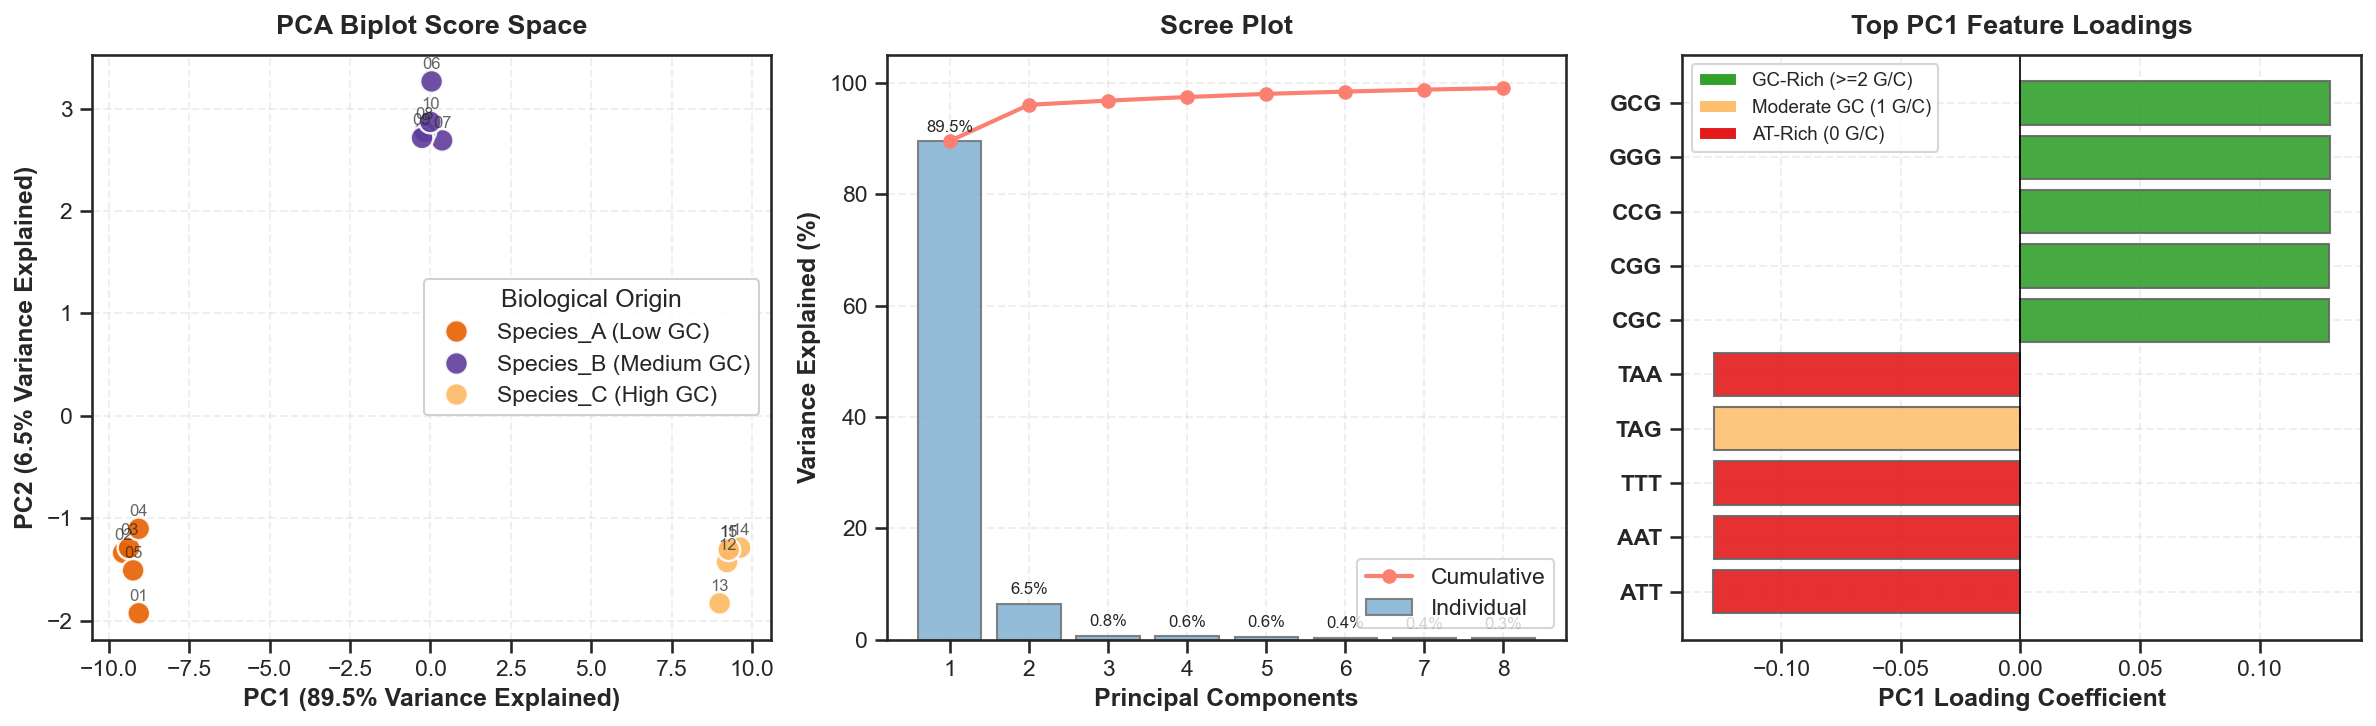

PCA plots successfully generated and saved to: ./pca_analysis.png


In [7]:
def plot_pca_results(pca_obj, pca_scores_df, data_df, output_path="pca_analysis.png"):
    """
    Generates a premium, publication-quality 3-panel PCA report.
    """
    fig = plt.figure(figsize=(16, 5))
    
    # Define a clean, high-contrast, professional HSL color palette
    colors = ['#E66101', '#5E3C99', '#FDB863']
    unique_classes = pca_scores_df["Species"].unique()
    palette = dict(zip(unique_classes, colors))
    
    # ----------------------------------------------------
    # PANEL 1: PCA Score Plot (PC1 vs PC2)
    # ----------------------------------------------------
    ax1 = fig.add_subplot(1, 3, 1)
    
    # Calculate explained variance for labels
    pc1_var = pca_obj.explained_variance_ratio_[0] * 100
    pc2_var = pca_obj.explained_variance_ratio_[1] * 100
    
    sns.scatterplot(
        data=pca_scores_df,
        x="PC1",
        y="PC2",
        hue="Species",
        palette=palette,
        s=120,
        edgecolor="w",
        linewidth=1.2,
        alpha=0.9,
        ax=ax1
    )
    
    # Enhance labels and style
    ax1.set_xlabel(f"PC1 ({pc1_var:.1f}% Variance Explained)", fontweight='bold')
    ax1.set_ylabel(f"PC2 ({pc2_var:.1f}% Variance Explained)", fontweight='bold')
    ax1.set_title("PCA Biplot Score Space", fontsize=13, pad=10, fontweight='bold')
    ax1.grid(True, linestyle="--", alpha=0.3)
    ax1.legend(title="Biological Origin", loc="best", framealpha=0.9)
    
    # Annotate points with short label
    for idx, row in pca_scores_df.iterrows():
        sample_num = idx.split("_")[1]
        ax1.annotate(
            sample_num,
            (row["PC1"], row["PC2"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha='center',
            fontsize=8,
            alpha=0.7
        )
        
    # ----------------------------------------------------
    # PANEL 2: Scree Plot (Explained Variance)
    # ----------------------------------------------------
    ax2 = fig.add_subplot(1, 3, 2)
    
    n_pcs = min(8, len(pca_obj.explained_variance_ratio_))
    pc_idx = np.arange(1, n_pcs + 1)
    individual_var = pca_obj.explained_variance_ratio_[:n_pcs] * 100
    cumulative_var = np.cumsum(pca_obj.explained_variance_ratio_[:n_pcs]) * 100
    
    # Draw bars for individual variance
    bars = ax2.bar(pc_idx, individual_var, color="#80B1D3", alpha=0.85, edgecolor="#707070", label="Individual")
    # Draw step line for cumulative variance
    line = ax2.plot(pc_idx, cumulative_var, color="#FB8072", marker="o", linewidth=2, label="Cumulative")
    
    # Labels and legend
    ax2.set_xlabel("Principal Components", fontweight='bold')
    ax2.set_ylabel("Variance Explained (%)", fontweight='bold')
    ax2.set_title("Scree Plot", fontsize=13, pad=10, fontweight='bold')
    ax2.set_xticks(pc_idx)
    ax2.set_ylim(0, 105)
    ax2.grid(True, linestyle="--", alpha=0.3)
    
    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom', fontsize=8
        )
    ax2.legend(loc="lower right")
    
    # ----------------------------------------------------
    # PANEL 3: Feature Loadings Analysis
    # ----------------------------------------------------
    ax3 = fig.add_subplot(1, 3, 3)
    
    loadings = pd.DataFrame(
        pca_obj.components_.T,
        columns=[f"PC{i+1}" for i in range(len(pca_obj.components_))],
        index=data_df.columns
    )
    
    # Identify the top 5 positive and top 5 negative loading features on PC1
    pc1_sorted = loadings["PC1"].sort_values()
    top_negative = pc1_sorted.head(5)
    top_positive = pc1_sorted.tail(5)
    key_features = pd.concat([top_negative, top_positive])
    
    # Color coding features by their expected GC content character
    def get_gc_color(kmer):
        gc_count = sum(1 for c in kmer if c in "GC")
        if gc_count >= 2:
            return "#33A02C"
        elif gc_count == 1:
            return "#FDBF6F"
        else:
            return "#E31A1C"
            
    feature_colors = [get_gc_color(km) for km in key_features.index]
    
    # Create horizontal bar plot for loading values
    y_pos = np.arange(len(key_features))
    ax3.barh(y_pos, key_features.values, color=feature_colors, edgecolor="#666666", alpha=0.9)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(key_features.index, fontweight='bold')
    ax3.set_xlabel("PC1 Loading Coefficient", fontweight='bold')
    ax3.set_title("Top PC1 Feature Loadings", fontsize=13, pad=10, fontweight='bold')
    ax3.axvline(0, color="black", linestyle="-", linewidth=0.8)
    ax3.grid(True, linestyle="--", alpha=0.3)
    
    # Custom legend for loading types
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#33A02C", label="GC-Rich (>=2 G/C)"),
        Patch(facecolor="#FDBF6F", label="Moderate GC (1 G/C)"),
        Patch(facecolor="#E31A1C", label="AT-Rich (0 G/C)")
    ]
    ax3.legend(handles=legend_elements, loc="best", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"PCA plots successfully generated and saved to: {output_path}")

# Run visualization
plot_pca_results(pca_model, pca_scores, expression_matrix, output_path="./pca_analysis.png")

## 4. Interpretation of Results
- **PC1 Separation**: PC1 captures the majority of variance. In our loadings plot, GC-rich $k$-mers 
  (e.g., GCG, CGC, CCG) have highly positive loadings, while AT-rich $k$-mers (e.g., ATT, ATA, TAA) 
  have negative loadings. This aligns perfectly with our simulated species where GC-content was 30% vs 50% vs 70%.
  Thus, PC1 represents a **GC-content gradient** in the genomes.
- **PC2 Separation**: PC2 captures differences orthogonal to GC content. Notice how Species B (Medium GC) 
  separates on PC2 from the general trend. This is due to the synthetic enrichment of the `CGATCG` motif 
  introduced specifically in Species B, showing how PCA picks up sub-patterns beyond base composition.